# HHL Algorithm: A Toy Linear System, Solutions

In [1]:
!pip install qiskit --quiet
!pip install qiskit[visualization] --quiet
!pip install qiskit_aer --quiet


In [2]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.quantum_info import Statevector

A = np.array([[1.5, -0.5], [-0.5, 1.5]])
b_vec = np.array([0, 1])

eigvals, eigvecs = np.linalg.eigh(A)
print("Eigenvalues of A:", eigvals)

t = np.pi / 2
U = expm(1j * A * t)
U2 = U @ U
print("U is unitary:", np.allclose(U @ U.conj().T, np.eye(2)))


Eigenvalues of A: [1. 2.]
U is unitary: True


## Answers 1 to 4: state prep, QPE, controlled rotation, uncompute

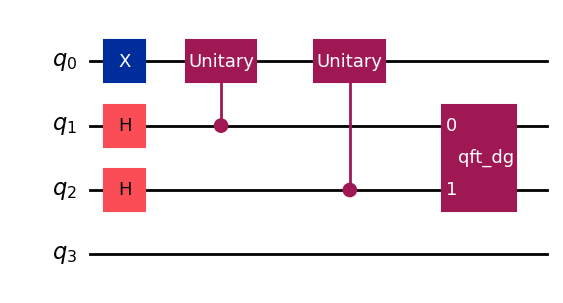

In [3]:
SYS, C0, C1, ANC = 0, 1, 2, 3

qc = QuantumCircuit(4)

# SOLUTION 1: prepare |b> = |1>
qc.x(SYS)

# SOLUTION 2: Hadamards on the clock register
qc.h([C0, C1])

# SOLUTION 3: controlled-U on C0, controlled-U^2 on C1
cu1 = UnitaryGate(U).control(1)
cu2 = UnitaryGate(U2).control(1)
qc.append(cu1, [C0, SYS])
qc.append(cu2, [C1, SYS])

# SOLUTION 4: inverse QFT on the clock register
qc.append(QFTGate(2).inverse(), [C0, C1])

qc.draw('mpl')


In [4]:
# SOLUTION 5: controlled rotation on the ancilla
C = 1.0
theta_lambda1 = 2 * np.arcsin(C / 1)
theta_lambda2 = 2 * np.arcsin(C / 2)

# clock == '01' means C0=1, C1=0
qc.x(C1)
qc.mcry(theta_lambda1, [C0, C1], ANC)
qc.x(C1)

# clock == '10' means C0=0, C1=1
qc.x(C0)
qc.mcry(theta_lambda2, [C0, C1], ANC)
qc.x(C0)


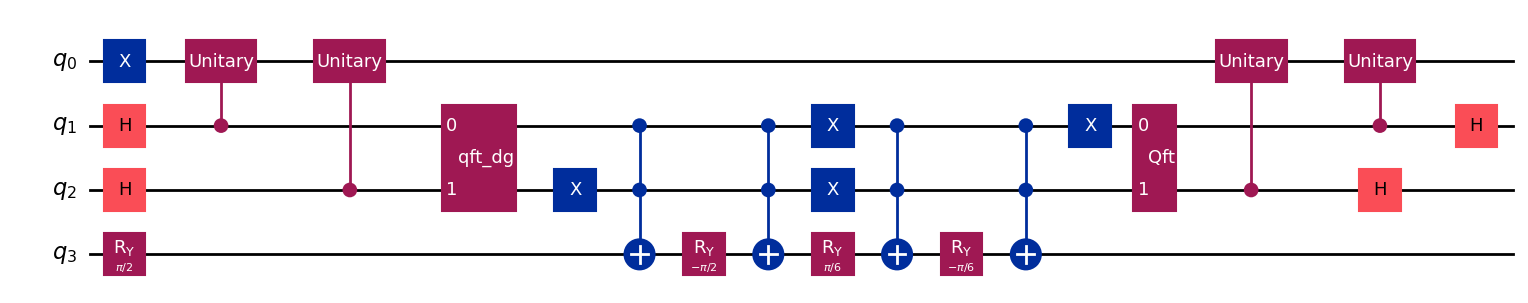

In [5]:
# SOLUTION 6: uncompute the QPE, in reverse order
qc.append(QFTGate(2), [C0, C1])
qc.append(cu2.inverse(), [C1, SYS])
qc.append(cu1.inverse(), [C0, SYS])
qc.h([C0, C1])

qc.draw('mpl')


## Answer 7: extract and check the result

In [6]:
sv = Statevector.from_instruction(qc)

amp_sys0 = sv.data[int('1000', 2)]
amp_sys1 = sv.data[int('1001', 2)]

result_vec = np.array([amp_sys0, amp_sys1])
print("Unnormalized quantum solution:", result_vec)
print("Normalized quantum solution:  ", result_vec / np.linalg.norm(result_vec))

classical = np.linalg.solve(A, b_vec)
print("Normalized classical solution:", classical / np.linalg.norm(classical))

p_success = sum(v for k, v in sv.probabilities_dict().items() if k[0] == '1')
print(f"P(ancilla=1) success probability: {p_success:.3f}")


Unnormalized quantum solution: [0.25+5.82867088e-16j 0.75-2.24126273e-15j]
Normalized quantum solution:   [0.31622777+7.37275028e-16j 0.9486833 -2.83499803e-15j]
Normalized classical solution: [0.31622777 0.9486833 ]
P(ancilla=1) success probability: 0.625


**Expected result:** normalized quantum solution $[0.316, 0.949]$, matching the classical solution to machine precision. Success probability of the ancilla postselection is about 0.625.

**Why C must be at most the smallest eigenvalue:** $\arcsin$ is only defined for arguments between -1 and 1. If C were larger than the smallest eigenvalue (here, 1), then $C/\lambda$ would exceed 1 for that eigenvalue and $\arcsin(C/\lambda)$ would be undefined (in practice, most implementations would just throw an error or return NaN). Choosing C equal to the smallest eigenvalue is the largest safe choice, and it also maximizes the ancilla's success probability, since $P(\text{ancilla}=1)$ scales with $C^2$ summed appropriately over the eigenvalue weights.

**On postselection overhead:** if the success probability were very small (say 1 in a million), you would need to repeat the whole circuit roughly a million times on average just to get one usable sample, which would erase any exponential speedup HHL promises for the parts of the algorithm before postselection. This is one of the real practical caveats behind HHL's headline complexity result, and it is why HHL's advantage depends heavily on the condition number of A (the ratio of largest to smallest eigenvalue) staying manageable.


## Extension: $b = |0\rangle$

In [7]:
qc2 = QuantumCircuit(4)
# no x on SYS this time: |b> = |0>

qc2.h([C0, C1])
qc2.append(cu1, [C0, SYS])
qc2.append(cu2, [C1, SYS])
qc2.append(QFTGate(2).inverse(), [C0, C1])

qc2.x(C1)
qc2.mcry(theta_lambda1, [C0, C1], ANC)
qc2.x(C1)
qc2.x(C0)
qc2.mcry(theta_lambda2, [C0, C1], ANC)
qc2.x(C0)

qc2.append(QFTGate(2), [C0, C1])
qc2.append(cu2.inverse(), [C1, SYS])
qc2.append(cu1.inverse(), [C0, SYS])
qc2.h([C0, C1])

sv2 = Statevector.from_instruction(qc2)
amp0_2 = sv2.data[int('1000', 2)]
amp1_2 = sv2.data[int('1001', 2)]
vec2 = np.array([amp0_2, amp1_2])
print("Normalized quantum solution:  ", vec2 / np.linalg.norm(vec2))

classical2 = np.linalg.solve(A, np.array([1, 0]))
print("Normalized classical solution:", classical2 / np.linalg.norm(classical2))


Normalized quantum solution:   [0.9486833 -2.28204175e-16j 0.31622777+2.80866677e-16j]
Normalized classical solution: [0.9486833  0.31622777]


**Expected result:** $[0.949, 0.316]$ both ways. The circuit correctly gets the new answer with no structural changes, only the initial state preparation changed.